# 📚 Section 6. Relationship Chart — Scatter Plot / Bubble Chart
> 섹션 6. 관계 차트 — Scatter Plot / Bubble Chart

---
# 🎯 Learning Objective · 학습 목표
Today I want to learn: · 오늘 배우고 싶은 것:
- [x] Read a Scatter Plot for correlation direction and strength, and back it up with a numeric correlation coefficient  
Scatter Plot에서 상관관계의 방향과 강도를 읽고, 상관계수로 숫자 근거를 뒷받침하기
- [x] Add a regression trend line with numpy.polyfit and interpret its slope as a real-world rate  
numpy.polyfit으로 회귀 추세선을 추가하고 기울기를 실제 비율로 해석하기
- [x] Build a Bubble Chart that encodes a 3rd (and 4th) variable as size (and color)  
3번째(및 4번째) 변수를 크기(및 색상)로 인코딩하는 Bubble Chart 만들기

---
# 🧠 Concept · 개념

## What is it? · 무엇인가?

A Scatter Plot places two continuous variables on the x and y axes and draws each observation as a point, revealing the relationship (correlation) between them.

Scatter Plot은 두 연속형 변수를 각각 x축, y축에 놓고 각 관측치를 점으로 표시하여, 두 변수 사이의 관계(상관관계)를 보여주는 차트입니다.

## Why do we use it? · 왜 사용하는가?

Use it to answer "does A go up when B goes up (or down)?" and to spot clusters or outliers that a table of numbers would never reveal.

"A가 커지면 B도 커지는가/작아지는가?" 같은 상관관계를 확인하고 싶을 때, 데이터의 군집이나 이상치를 발견하고 싶을 때 사용합니다.

## When is it used in Business Analytics? · 언제 비즈니스 분석에서 사용되는가?

DA/BA situations: ad spend vs revenue, price vs sales volume, customer age vs purchase amount, tenure vs salary — anywhere you need to see the relationship between two metrics.

DA/BA 실무 상황: 광고비 대비 매출, 가격 대비 판매량, 고객 나이 대비 구매액, 근속연수 대비 급여 등 두 지표 사이의 관계를 파악할 때.

A Bubble Chart is a Scatter Plot with a 3rd variable added as point size (and optionally a 4th as color):

Bubble Chart는 Scatter Plot에 3번째 변수를 점 크기로 추가한 것입니다(선택적으로 4번째 변수를 색상으로 추가):

| | Scatter Plot | Bubble Chart |
|---|---|---|
| Variables shown / 표현 변수 | 2 (x, y) | 3-4 (x, y, size, optionally color) |
| Best for / 적합한 상황 | Just the relationship between two variables / 변수 2개의 관계만 확인 | Relationship + "scale" together / 관계 + "규모"까지 함께 표현 |
| Watch out for / 주의점 | Many overlapping points need low alpha / 점이 매우 많으면 낮은 alpha 필요 | Overlap gets worse than Scatter with many bubbles / 버블이 많으면 겹침이 Scatter보다 더 심함 |

---
# 📝 Syntax · 문법

## Basic Syntax · 기본 문법

`ax.scatter(x, y)` draws one point per observation. Pair it with `np.corrcoef()` to get a numeric correlation coefficient alongside the visual — the eye can be fooled, but the number is a useful check.

`ax.scatter(x, y)`는 관측치마다 점 하나를 그립니다. `np.corrcoef()`와 함께 쓰면 시각적 판단 옆에 숫자로 된 상관계수를 확보할 수 있습니다 — 눈은 착각할 수 있지만 숫자는 유용한 검증 수단입니다.

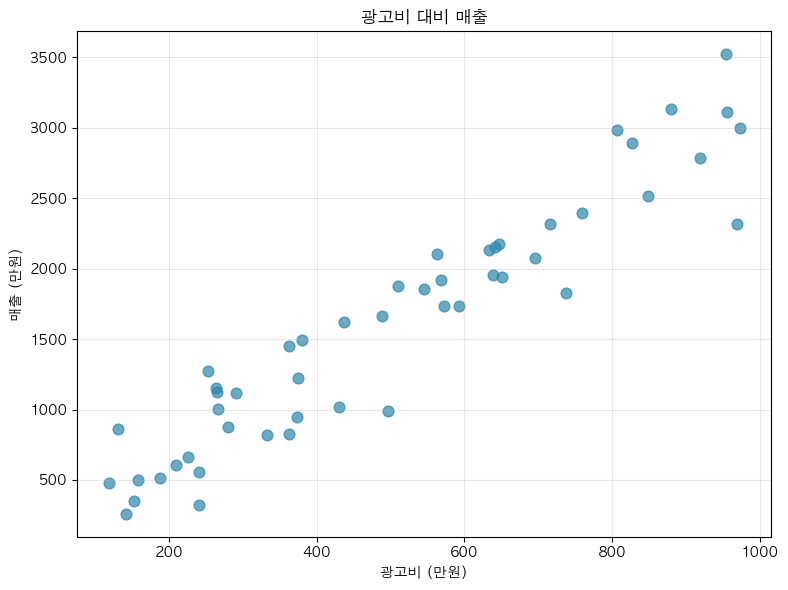

Correlation coefficient / 상관계수: 0.947


In [8]:
# Basic Syntax: a scatter plot with a numeric correlation check
# 기본 문법: 상관계수를 함께 확인하는 산점도

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'   # macOS: 'AppleGothic', Windows: 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
ad_spend = np.random.uniform(100, 1000, 50)
revenue = ad_spend * 3.2 + np.random.normal(0, 300, 50)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(ad_spend, revenue, color='#2E86AB', alpha=0.7, s=60)
ax.set_title('광고비 대비 매출')
ax.set_xlabel('광고비 (만원)')
ax.set_ylabel('매출 (만원)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

corr = np.corrcoef(ad_spend, revenue)[0, 1]
print(f"Correlation coefficient / 상관계수: {corr:.3f}")

## Common Variations · 주요 변형

`numpy.polyfit(x, y, 1)` fits a straight line through the points and returns `[slope, intercept]`. Plotting that line on top of the scatter turns "there seems to be a relationship" into a concrete, quotable number.

`numpy.polyfit(x, y, 1)`은 점들을 관통하는 직선을 피팅해 `[기울기, 절편]`을 반환합니다. 그 선을 산점도 위에 함께 그리면 "관계가 있어 보인다"가 구체적으로 인용 가능한 숫자로 바뀝니다.

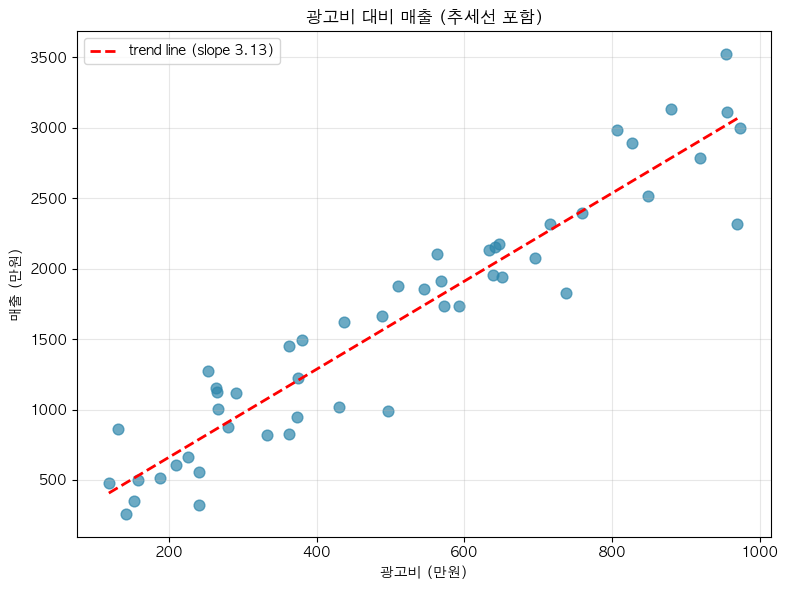

In [2]:
# Common Variations: adding a regression trend line
# 주요 변형: 회귀 추세선 추가하기

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
ad_spend = np.random.uniform(100, 1000, 50)
revenue = ad_spend * 3.2 + np.random.normal(0, 300, 50)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(ad_spend, revenue, color='#2E86AB', alpha=0.7, s=60)

z = np.polyfit(ad_spend, revenue, 1)          # [slope, intercept]
p = np.poly1d(z)
x_line = np.linspace(ad_spend.min(), ad_spend.max(), 100)
ax.plot(x_line, p(x_line), color='red', linestyle='--', linewidth=2,
        label=f'trend line (slope {z[0]:.2f})')

ax.set_title('광고비 대비 매출 (추세선 포함)')
ax.set_xlabel('광고비 (만원)')
ax.set_ylabel('매출 (만원)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# 🧪 Small Examples · 예제

## Example 1: Comparing Two Groups' Regression Slopes · 예제 1: 두 그룹의 회귀 기울기 비교

Fitting a separate trend line per group turns a single scatter plot into a mini ROI comparison — a steeper slope means more output per unit of input.

그룹별로 별도의 추세선을 피팅하면 산점도 하나가 작은 ROI 비교 도구가 됩니다 — 기울기가 가파를수록 투입 대비 산출이 큽니다.

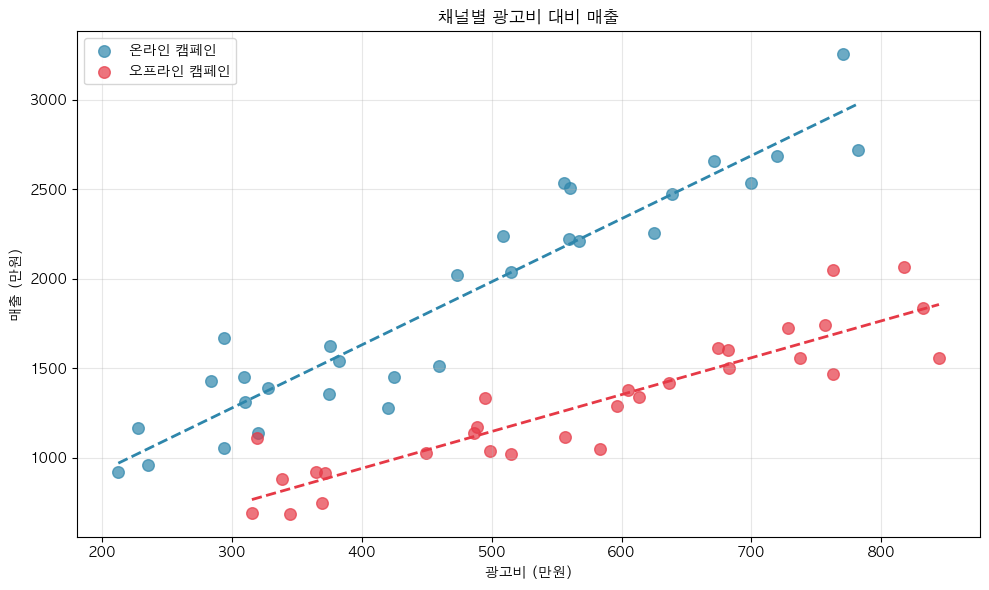

Online slope / 온라인 기울기: 3.52  (revenue per 1 unit of ad spend)
Offline slope / 오프라인 기울기: 2.06  (revenue per 1 unit of ad spend)


In [3]:
# Example 1: online vs offline ad spend efficiency
# 예제 1: 온라인 vs 오프라인 광고비 효율성

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
n = 30
online_spend = np.random.uniform(200, 800, n)
online_revenue = online_spend * 4.1 + np.random.normal(0, 250, n)
offline_spend = np.random.uniform(300, 900, n)
offline_revenue = offline_spend * 2.3 + np.random.normal(0, 200, n)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(online_spend, online_revenue, color='#2E86AB', alpha=0.7, s=70, label='온라인 캠페인')
ax.scatter(offline_spend, offline_revenue, color='#E63946', alpha=0.7, s=70, label='오프라인 캠페인')

z_online = np.polyfit(online_spend, online_revenue, 1)
z_offline = np.polyfit(offline_spend, offline_revenue, 1)
x_on = np.linspace(online_spend.min(), online_spend.max(), 100)
x_off = np.linspace(offline_spend.min(), offline_spend.max(), 100)
ax.plot(x_on, np.poly1d(z_online)(x_on), color='#2E86AB', linestyle='--', linewidth=2)
ax.plot(x_off, np.poly1d(z_offline)(x_off), color='#E63946', linestyle='--', linewidth=2)

ax.set_title('채널별 광고비 대비 매출')
ax.set_xlabel('광고비 (만원)')
ax.set_ylabel('매출 (만원)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Online slope / 온라인 기울기: {z_online[0]:.2f}  (revenue per 1 unit of ad spend)")
print(f"Offline slope / 오프라인 기울기: {z_offline[0]:.2f}  (revenue per 1 unit of ad spend)")

## Example 2: Bubble Chart Basics · 예제 2: Bubble Chart 기본

The `s=` parameter controls point *area*, so a 3rd variable can be encoded as bubble size. Raw values are usually too large to use directly — scale them down first.

`s=` 파라미터는 점의 *면적*을 조절하므로, 3번째 변수를 버블 크기로 인코딩할 수 있습니다. 원본 값은 보통 그대로 쓰기엔 너무 크므로, 먼저 적절히 축소해야 합니다.

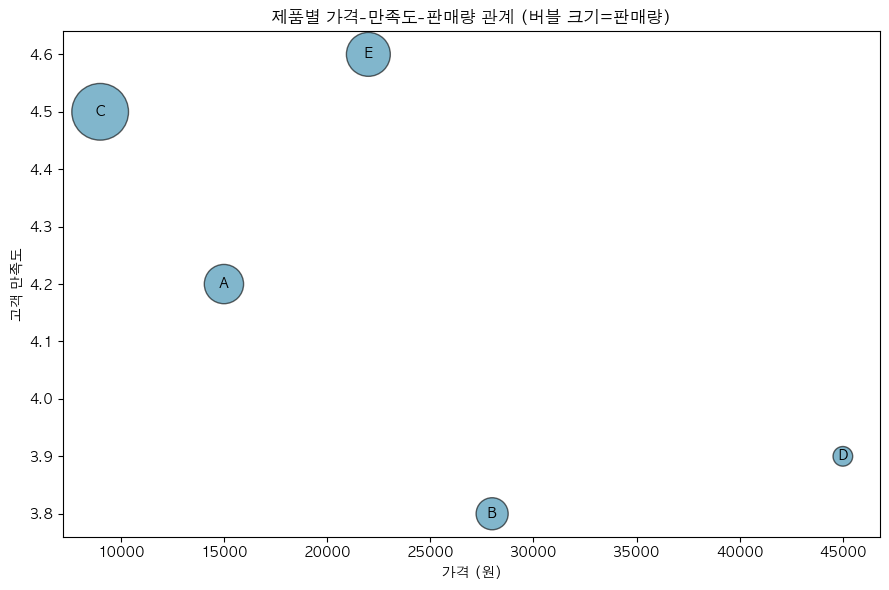

In [11]:
# Example 2: price, satisfaction, and sales volume in one chart
# 예제 2: 가격, 만족도, 판매량을 하나의 차트에

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

products = ['A', 'B', 'C', 'D', 'E']
price = [15000, 28000, 9000, 45000, 22000]
satisfaction = [4.2, 3.8, 4.5, 3.9, 4.6]
sales_volume = [1200, 800, 2500, 300, 1500]

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(price, satisfaction, s=[v / 1.5 for v in sales_volume],
           color='#2E86AB', alpha=0.6, edgecolors='black')

for i, name in enumerate(products):
    ax.annotate(name, (price[i], satisfaction[i]), ha='center', va='center', fontweight='bold')

ax.set_title('제품별 가격-만족도-판매량 관계 (버블 크기=판매량)')
ax.set_xlabel('가격 (원)')
ax.set_ylabel('고객 만족도')
plt.tight_layout()
plt.show()

## Example 3: Practice · 예제 3: 연습문제

**Part A** rebuilds a tenure-vs-salary scatter with a trend line — fill in a dot color. **Part B** rebuilds a city population/income/store-count bubble chart — fill in a size multiplier. Both run without error either way; the real chart appears once the blank is filled in.

**Part A**는 근속연수-연봉 산점도와 추세선을 다시 만듭니다 — 점 색상을 채우세요. **Part B**는 도시별 인구-소득-매장수 버블 차트를 다시 만듭니다 — 크기 배율을 채우세요. 둘 다 어떤 상태든 에러 없이 실행되며, 빈칸을 채워야만 실제 차트가 나타납니다.

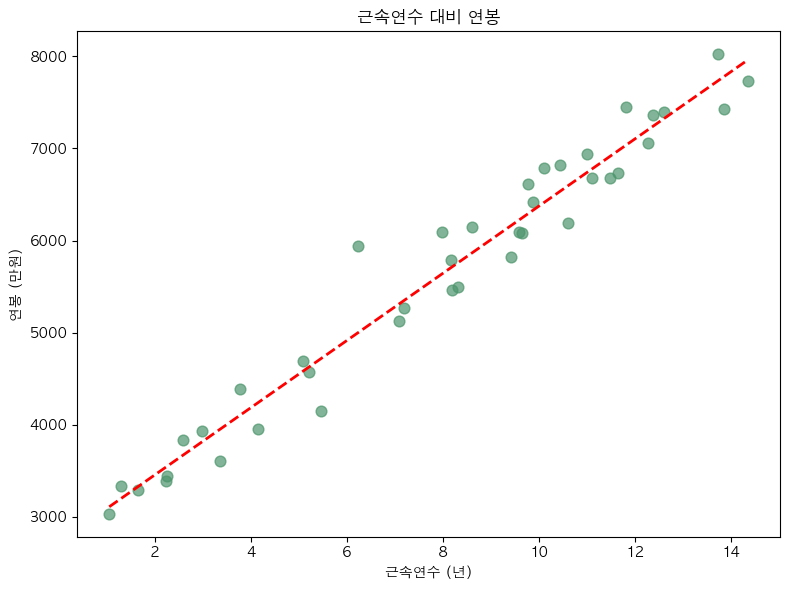

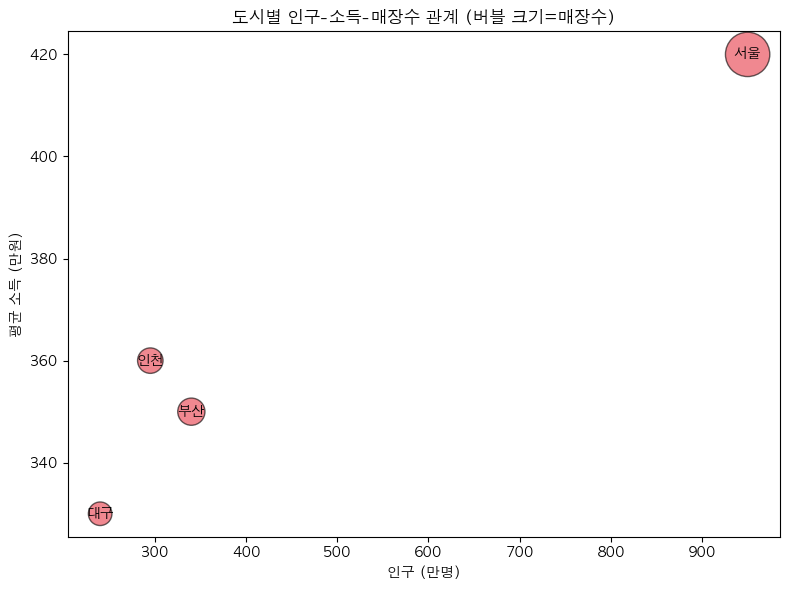

In [15]:
# Practice: fill in the blanks, then re-run this cell
# 연습문제: 빈칸을 채운 후 셀을 다시 실행하세요

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ---- Part A: tenure vs salary scatter + trend line ----
# ---- Part A: 근속연수 대비 연봉 산점도 + 추세선 ----
np.random.seed(10)
experience = np.random.uniform(1, 15, 40)
salary = experience * 350 + np.random.normal(0, 400, 40) + 2800

dot_color = "#4C956C"    # TODO: any valid color, e.g. '#4C956C'

if dot_color == "________":
    print("Part A: fill in dot_color above, then re-run.")
    print("Part A: 위의 dot_color를 채운 후 다시 실행하세요.")
else:
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(experience, salary, color=dot_color, alpha=0.7, s=60)
    z = np.polyfit(experience, salary, 1)
    p = np.poly1d(z)
    x_line = np.linspace(experience.min(), experience.max(), 100)
    ax.plot(x_line, p(x_line), color='red', linestyle='--', linewidth=2)
    ax.set_title('근속연수 대비 연봉')
    ax.set_xlabel('근속연수 (년)')
    ax.set_ylabel('연봉 (만원)')
    plt.tight_layout()
    plt.show()

# ---- Part B: city population/income/store-count bubble chart ----
# ---- Part B: 도시별 인구-소득-매장수 버블 차트 ----
cities = ['서울', '부산', '대구', '인천']
population = [950, 340, 240, 295]
avg_income = [420, 350, 330, 360]
store_count = [85, 32, 24, 28]

size_multiplier = 12    # TODO: a number, e.g. 8

if size_multiplier == "________":
    print("Part B: fill in size_multiplier above, then re-run.")
    print("Part B: 위의 size_multiplier를 채운 후 다시 실행하세요.")
else:
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(population, avg_income, s=[c * size_multiplier for c in store_count],
               color='#E63946', alpha=0.6, edgecolors='black')
    for i, name in enumerate(cities):
        ax.annotate(name, (population[i], avg_income[i]), ha='center', va='center', fontweight='bold')
    ax.set_title('도시별 인구-소득-매장수 관계 (버블 크기=매장수)')
    ax.set_xlabel('인구 (만명)')
    ax.set_ylabel('평균 소득 (만원)')
    plt.tight_layout()
    plt.show()

---
# ⚠️ Common Mistakes · 자주 하는 실수

### Mistake 1: Too many overlapping points without alpha · 실수 1: 점이 매우 많은데 alpha 없이 그림

With thousands of points, they overlap so heavily that density becomes invisible and everything looks like one solid blob.

점이 수천 개 이상이면 서로 심하게 겹쳐 밀도가 안 보이고 하나의 덩어리처럼 뭉개져 보입니다.

✅ **Fix:** Lower `alpha` to 0.1-0.3, or switch to a 2D histogram (`ax.hexbin()`) for very dense data.  
✅ **해결:** `alpha`를 0.1~0.3으로 낮추거나, 데이터가 매우 많으면 2D 히스토그램(`ax.hexbin()`) 사용을 고려하세요.

### Mistake 2: Treating correlation as causation · 실수 2: 상관관계를 인과관계로 단정

Seeing a trend line and concluding "increasing A causes B to increase" isn't something a scatter plot alone can prove — the correlation coefficient measures strength of relationship, not cause.

추세선을 보고 "A를 늘리면 B가 늘어난다"고 결론짓는 것은 산점도 하나만으로는 증명할 수 없습니다 — 상관계수는 관계의 강도만 보여줄 뿐, 원인을 증명하지 않습니다.

✅ **Fix:** Present correlation findings as "these move together," and be explicit that proving causation requires controlled experiments or further analysis.  
✅ **해결:** 상관관계 결과는 "함께 움직인다"로 표현하고, 인과관계 증명에는 통제된 실험이나 추가 분석이 필요하다는 점을 명시하세요.

### Mistake 3: One outlier skewing the whole regression line · 실수 3: 이상치 하나 때문에 회귀선이 왜곡

A single extreme point can pull `polyfit()`'s line far from where most of the data actually sits, making the fitted trend line misleading.

극단적인 점 하나가 `polyfit()`의 회귀선을 실제 데이터 대부분이 위치한 곳에서 멀리 끌어당겨, 피팅된 추세선이 오해를 일으킬 수 있습니다.

✅ **Fix:** Check for outliers (a Box Plot from Section 5 works well) before trusting a regression line drawn on top of a scatter.  
✅ **해결:** 산점도 위에 회귀선을 그리기 전에 이상치를 먼저 확인하세요 (섹션 5의 Box Plot이 유용합니다).

### Mistake 4: Not adjusting the axis scale when variables differ wildly in size · 실수 4: 두 변수의 스케일 차이가 큰데 축 조정 안 함

When one variable ranges in the hundreds and the other in the millions, most points bunch up in a corner and the relationship becomes impossible to see on a plain linear axis.

한 변수는 수백 단위이고 다른 변수는 수백만 단위라면, 대부분의 점이 한쪽 구석에 몰려 일반 선형 축에서는 관계를 알아보기 어려워집니다.

✅ **Fix:** Try a log scale on the skewed axis with `ax.set_xscale('log')` (or `set_yscale`) when values span several orders of magnitude.  
✅ **해결:** 값의 범위가 여러 자릿수에 걸쳐 있다면 치우친 축에 `ax.set_xscale('log')`(또는 `set_yscale`)로 로그 스케일을 시도하세요.

### Mistake 5: Passing raw values directly to s= · 실수 5: s=에 원본 값을 그대로 사용

Passing an unscaled variable (like a value in the thousands) straight into `s=` produces bubbles so large they blot out the chart, or so tiny they vanish.

크기가 수천 단위인 값을 스케일 조정 없이 그대로 `s=`에 넣으면, 버블이 화면을 뒤덮을 정도로 커지거나 점처럼 너무 작아집니다.

✅ **Fix:** Divide or multiply the values by an appropriate factor so bubble sizes land in a reasonable range for your figure size.  
✅ **해결:** 데이터 범위에 맞게 나누기/곱하기로 배율을 조정해 Figure 크기에 맞는 버블 크기로 만드세요.

### Mistake 6: Forgetting that size is proportional to area, not radius · 실수 6: 크기가 "반지름"이 아니라 "면적"에 비례함을 모름

`s=` scales point *area*. Doubling a value doesn't double the visible radius — it only grows the radius by about 1.4x, which can look like a much smaller difference than intended.

`s=`는 점의 *면적*을 조절합니다. 값을 2배로 늘려도 눈에 보이는 반지름은 2배가 아니라 약 1.4배만 커져서, 의도한 것보다 차이가 작아 보일 수 있습니다.

✅ **Fix:** When an exact size comparison matters, scale with `s = value ** 0.5 * factor` to make the *radius* proportional instead of the area.  
✅ **해결:** 정확한 크기 비교가 중요하면 `s = 값 ** 0.5 * 배율`처럼 제곱근 스케일링을 적용해 면적이 아닌 반지름을 비례하게 만드세요.

### Mistake 7: Showing many bubbles with no size legend · 실수 7: 크기 범례 없이 버블만 표시

Without a reference, viewers can compare bubbles to *each other* but have no way to know what any single bubble's size actually means in real units.

기준이 없으면 보는 사람은 버블끼리 서로 비교는 할 수 있지만, 각 버블의 크기가 실제로 어떤 값을 의미하는지는 알 수 없습니다.

✅ **Fix:** Add a few reference bubbles of known size as a legend (e.g. small circle = 100, large circle = 500), the same way Business Example below adds a color legend with empty `scatter([], [])` calls.  
✅ **해결:** 대표적인 크기 몇 개를 알려진 값으로 범례에 표시하세요 (예: 작은 원=100, 큰 원=500) — 아래 Business Example이 빈 `scatter([], [])` 호출로 색상 범례를 추가하는 것과 같은 방식입니다.

---
# 💡 Tips · 팁
Useful tips or shortcuts · 유용한 팁과 지름길

- Always compute `np.corrcoef()` alongside a scatter plot — a number is a useful sanity check on what your eyes think they see.  
산점도 옆에는 항상 `np.corrcoef()`를 함께 계산하세요 — 눈으로 본 것을 검증하는 데 숫자가 유용합니다.
- Check for outliers before trusting a regression line; one extreme point can pull the whole fit off course.  
회귀선을 신뢰하기 전에 이상치를 먼저 확인하세요, 극단값 하나가 전체 피팅을 왜곡시킬 수 있습니다.
- For a Bubble Chart, scale raw values before passing them to `s=`, and remember size represents area, not radius.  
Bubble Chart에서는 원본 값을 `s=`에 넣기 전에 스케일을 조정하고, 크기가 반지름이 아니라 면적을 의미한다는 점을 기억하세요.
- An empty `ax.scatter([], [], label=...)` call is a simple trick to add a legend entry without plotting any actual data — handy for color legends on bubble charts.  
빈 `ax.scatter([], [], label=...)` 호출은 실제 데이터 없이 범례 항목만 추가하는 간단한 트릭입니다 — 버블 차트의 색상 범례에 유용합니다.

---
# 🔗 Related Concepts · 관련 개념

```
   Section 5: Distribution Charts   (purpose: Distribution, one variable)
                ↓
   Section 6: Relationship Charts   ←  YOU ARE HERE / 지금 여기
   (purpose: Relationship - correlation between 2+ variables)
   Scatter Plot -> Bubble Chart  (add a 3rd/4th variable as size/color)
                ↓
   Section 7: Ratio Charts (Pie / Donut / Treemap)
                ↓
   Section 8: Composite & Special Charts
```

*How is today's topic connected to other concepts?* · *오늘 배운 내용이 다른 개념과 어떻게 연결되는가?*

This section directly answers Section 1's "Relationship" purpose row. The Bubble Chart's core idea — encoding an extra variable through a visual channel beyond x/y position, like size or color — is the same idea behind Section 8's Heatmap (encoding value through color intensity) and Section 9's multi-panel dashboards (encoding a whole extra dimension through a separate chart entirely).

이 섹션은 섹션 1의 "관계" 행에 대한 직접적인 답입니다. Bubble Chart의 핵심 아이디어 — x/y 위치를 넘어 크기나 색상 같은 시각적 채널로 추가 변수를 인코딩하는 것 — 는 섹션 8의 Heatmap(색상 진하기로 값 인코딩)과 섹션 9의 여러 패널 대시보드(별도의 차트 하나로 완전히 다른 차원을 인코딩)에서도 같은 아이디어로 다시 등장합니다.

---
# 💼 Business Example · 비즈니스 예제
*How would a Business Analyst use this?* · *비즈니스 분석가는 이것을 어떻게 활용할까?*

**Scenario / 시나리오:**
Your manager wants to know which branches are truly "efficient" — not just which have the most staff or the most revenue, but which get the most revenue *per employee* while staying profitable, and whether that differs by region type.

매니저가 어느 지점이 진짜 "효율적"인지 알고 싶어 합니다 — 단순히 직원이 많거나 매출이 큰 지점이 아니라, 직원 1인당 매출이 가장 높으면서 수익성도 유지하는 지점, 그리고 그것이 지역 유형에 따라 다른지를 알고 싶어 합니다.

**To-Do / 할 일:**
- [x] Plot employee count (x) vs revenue (y) as bubbles, sized by profit  
직원 수(x)와 매출(y)을 순이익 크기의 버블로 표시하기
- [x] Color-code branches by region type (수도권 vs 지방) with a proper legend  
지역 유형(수도권 vs 지방)별로 색상을 구분하고 범례 추가하기
- [x] Compute revenue-per-employee to identify the most efficient branch numerically  
직원 1인당 매출을 계산해 가장 효율적인 지점을 숫자로 확인하기

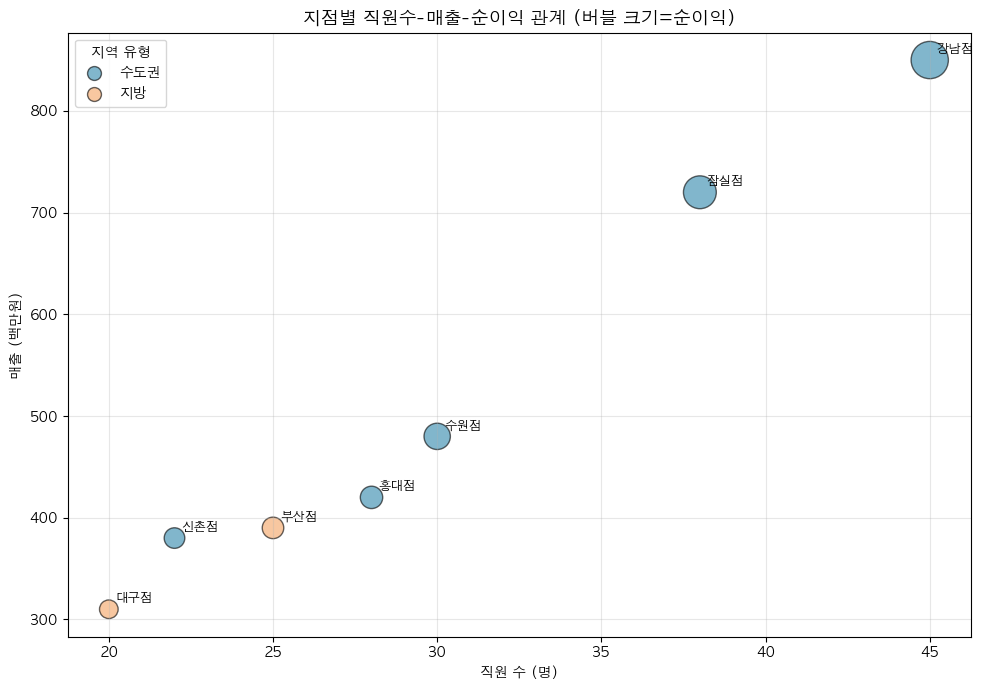

Revenue per employee by branch / 지점별 직원 1인당 매출:
  강남점: 18.9
  홍대점: 15.0
  신촌점: 17.3
  잠실점: 18.9
  수원점: 16.0
  부산점: 15.6
  대구점: 15.5

Most efficient / 가장 효율적: 잠실점 (18.9M per employee)


In [ ]:
# Business Example: branch efficiency - employees, revenue, and profit at once
# 비즈니스 예제: 지점 효율성 - 직원수, 매출, 순이익을 한 번에

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# self-contained dataset / 자체 포함형 데이터셋
branches = ['강남점', '홍대점', '신촌점', '잠실점', '수원점', '부산점', '대구점']
employees = [45, 28, 22, 38, 30, 25, 20]
revenue = [850, 420, 380, 720, 480, 390, 310]
profit = [180, 65, 55, 140, 90, 60, 45]
region_type = ['수도권', '수도권', '수도권', '수도권', '수도권', '지방', '지방']

colors_map = {'수도권': '#2E86AB', '지방': '#F4A261'}
colors = [colors_map[r] for r in region_type]

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(employees, revenue, s=[p * 4 for p in profit], c=colors,
           alpha=0.6, edgecolors='black', linewidth=1)

for i, name in enumerate(branches):
    ax.annotate(name, (employees[i], revenue[i]), xytext=(5, 5),
                textcoords='offset points', fontsize=9)

# empty scatter calls just to add legend entries for the colors
# 빈 scatter 호출로 색상 범례 항목만 추가
for region, color in colors_map.items():
    ax.scatter([], [], c=color, alpha=0.6, s=100, label=region, edgecolors='black')

ax.set_title('지점별 직원수-매출-순이익 관계 (버블 크기=순이익)', fontsize=13, fontweight='bold')
ax.set_xlabel('직원 수 (명)')
ax.set_ylabel('매출 (백만원)')
ax.legend(title='지역 유형')
ax.grid(True, alpha=0.3)
plt.tight_layout()
# fig.savefig('branch_efficiency_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

efficiency = [r / e for r, e in zip(revenue, employees)]
best_idx = efficiency.index(max(efficiency))
print(f"Revenue per employee by branch / 지점별 직원 1인당 매출:")
for name, eff in zip(branches, efficiency):
    print(f"  {name}: {eff:.1f}")
print(f"\nMost efficient / 가장 효율적: {branches[best_idx]} ({efficiency[best_idx]:.1f}M per employee)")

---
# 📝 Summary · 요약
*Write today's concept in 3~5 sentences.* · *오늘 배운 개념을 3~5문장으로 정리하세요.*

A Scatter Plot places two continuous variables on x and y to reveal their relationship, and pairing it with `np.corrcoef()` backs up what the eye sees with a real number. Adding a regression line via `np.polyfit(x, y, 1)` turns a vague "they seem related" into a concrete slope you can quote — and fitting separate lines per group, as in Example 1, turns that into an efficiency comparison. A Bubble Chart extends a Scatter Plot by encoding a 3rd variable as point size (remembering that size means area, not radius) and optionally a 4th as color, letting one chart carry 4 dimensions of information at once. Throughout, remember that correlation is not causation, and that a single outlier can meaningfully skew a fitted trend line.

Scatter Plot은 두 연속형 변수를 x축과 y축에 놓아 관계를 드러내며, `np.corrcoef()`와 함께 쓰면 눈으로 본 것을 실제 숫자로 뒷받침할 수 있습니다. `np.polyfit(x, y, 1)`로 회귀선을 추가하면 막연한 "관계가 있어 보인다"가 인용 가능한 구체적인 기울기로 바뀌며, Example 1처럼 그룹별로 각각 선을 피팅하면 효율성 비교 도구가 됩니다. Bubble Chart는 Scatter Plot을 확장해 3번째 변수를 점 크기로(크기는 반지름이 아니라 면적임을 기억하며) 인코딩하고, 선택적으로 4번째 변수를 색상으로 인코딩해 차트 하나에 4개 차원의 정보를 담습니다. 항상 상관관계가 인과관계는 아니라는 점, 그리고 이상치 하나가 피팅된 추세선을 의미 있게 왜곡할 수 있다는 점을 기억하세요.

---
# 📌 One Sentence Summary · 한 줄 요약
Today's topic in ONE sentence. · 오늘의 주제를 한 문장으로.

> A Scatter Plot reveals whether two variables move together, a regression line quantifies how strongly, and a Bubble Chart adds a 3rd (and 4th) variable as size and color — but none of it proves that one variable causes the other.

> Scatter Plot은 두 변수가 함께 움직이는지 보여주고, 회귀선은 그 강도를 수치화하며, Bubble Chart는 3번째(및 4번째) 변수를 크기와 색상으로 더하지만 — 어느 것도 한 변수가 다른 변수의 원인이라는 것을 증명하지는 않는다.

---
# ❓ Review Questions · 복습 문제

**Q1.** What does `np.corrcoef()` add to a scatter plot that the visual alone doesn't provide?
`np.corrcoef()`는 시각적으로만 볼 때는 얻을 수 없는 무엇을 산점도에 더해주는가?

**Q2.** Why is fitting separate regression lines for two groups (like online vs offline in Example 1) more informative than fitting one line for all the data combined?
왜 두 그룹에 각각 회귀선을 따로 피팅하는 것이(Example 1의 온라인 vs 오프라인처럼) 전체 데이터에 선 하나만 피팅하는 것보다 더 유용한 정보를 주는가?

**Q3.** In a Bubble Chart, why does doubling a data value not make the bubble look twice as big?
Bubble Chart에서 데이터 값을 2배로 늘려도 버블이 2배로 커 보이지 않는 이유는 무엇인가?

**Q4.** A colleague sees a strong correlation between ice cream sales and drowning incidents and concludes ice cream causes drowning. What's wrong with that conclusion?
동료가 아이스크림 판매량과 익사 사고 사이에 강한 상관관계를 보고 아이스크림이 익사를 유발한다고 결론짓는다. 이 결론의 문제는 무엇인가?

**Q5.** You need to show 4 variables — branch size, revenue, profit, and region type — in a single chart. Which chart from this section would you use, and which variable would you map to which visual channel?
지점 규모, 매출, 순이익, 지역 유형이라는 4개 변수를 하나의 차트에 보여줘야 한다. 이 섹션의 어떤 차트를 쓰겠으며, 어떤 변수를 어떤 시각적 채널에 매핑하겠는가?

---
*📅 Try answering these again in a few days.* · *📅 며칠 후에 다시 답해보세요.*